# 09 · Final Project

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/09-final-project/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Frame the problem and load the data

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data                         # 30 measurements per tumor: the features
y = (data.target == 0).astype(int)    # 1 = malignant, 0 = benign: the label

print(data.target_names.tolist())
print(X.shape)
print(X.columns[:4].tolist())
# ['malignant', 'benign']
# (569, 30)
# ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

['malignant', 'benign']
(569, 30)
['mean radius', 'mean texture', 'mean perimeter', 'mean area']


- Every tumor has a known answer, and the answer is a category: supervised binary classification ([lesson 01](../01-what-is-machine-learning/README.md)).
- scikit-learn codes malignant as `0`, because it comes first in `target_names`. We flip it so `1` means malignant. The class you're hunting becomes the "positive" class, so recall now means "cancers caught" ([lesson 03](../03-logistic-regression/README.md)).
- `as_frame=True` gives you a pandas DataFrame with named columns instead of a bare array.

### Step 2 · Explore before you model

In [2]:
print(y.value_counts())
print("share malignant:", round(y.mean(), 3))
print("missing values:", X.isna().sum().sum())
print(X[["mean area", "mean smoothness"]].describe().loc[["mean", "min", "max"]].round(3))
# target
# 0    357
# 1    212
# Name: count, dtype: int64
# share malignant: 0.373
# missing values: 0
#       mean area  mean smoothness
# mean    654.889            0.096
# min     143.500            0.053
# max    2501.000            0.163

target
0    357
1    212
Name: count, dtype: int64
share malignant: 0.373
missing values: 0
      mean area  mean smoothness
mean    654.889            0.096
min     143.500            0.053
max    2501.000            0.163


- **Balance:** 37% malignant. A lazy model that always says "benign" is already 63% accurate: the accuracy trap from [lesson 03](../03-logistic-regression/README.md). Every real model has to beat that baseline.
- **Gaps:** no missing values. That's lucky; real data usually has some. You'd fill them with a `SimpleImputer` placed *inside* the pipeline, so it also learns from training data only.
- **Scales:** area runs into the thousands while smoothness stays below 1. KNN and SVM measure distances, so area would drown out everything else unless you scale ([lesson 05](../05-knn-and-svm/README.md)).

### Step 3 · Split once, and lock the test set away

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("train:", X_train.shape, "  test:", X_test.shape)
print(f"share malignant   train: {y_train.mean():.3f}   test: {y_test.mean():.3f}")
# train: (455, 30)   test: (114, 30)
# share malignant   train: 0.374   test: 0.368

train: (455, 30)   test: (114, 30)
share malignant   train: 0.374   test: 0.368


- 114 tumors go into the vault. `X_test` and `y_test` won't be touched again until step 7.
- `stratify=y` keeps the malignant share almost identical in both parts. Without it, a small test set can end up with too few cancers just by bad luck.
- `random_state=42` makes the split repeatable: the same 114 tumors every time you run it.

### Step 4 · Scale inside a pipeline, one per model

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic regression": LogisticRegression(max_iter=1000),   # lesson 03
    "Random forest": RandomForestClassifier(random_state=42),   # lesson 04
    "KNN": KNeighborsClassifier(),                              # lesson 05
    "SVM": SVC(),                                               # lesson 05
    "Naive Bayes": GaussianNB(),                                # lesson 06
}
pipelines = {name: Pipeline([("scale", StandardScaler()), ("model", model)])
             for name, model in models.items()}

print(pipelines["KNN"])
# Pipeline(steps=[('scale', StandardScaler()), ('model', KNeighborsClassifier())])

Pipeline(steps=[('scale', StandardScaler()), ('model', KNeighborsClassifier())])


- Each pipeline is "scale, then model", glued into one object. `fit` learns the scaler's mean and standard deviation and then trains the model; `predict` reuses that same scaling, then predicts.
- Every model gets identical preprocessing, so the race is fair. Trees don't need scaling ([lesson 04](../04-decision-trees-and-random-forests/README.md)), but it doesn't hurt them either.
- Nothing has learned anything yet. These are five untrained recipes, waiting for data.

### Step 5 · Compare the models with cross-validation

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv)   # accuracy on each of 5 folds
    cv_scores[name] = scores
    print(f"{name:<20} {scores.mean():.3f} ± {scores.std():.3f}")

best = max(cv_scores, key=lambda name: cv_scores[name].mean())
print("winner:", best)
# Logistic regression  0.974 ± 0.015
# Random forest        0.965 ± 0.015
# KNN                  0.965 ± 0.019
# SVM                  0.971 ± 0.005
# Naive Bayes          0.938 ± 0.026
# winner: Logistic regression

Logistic regression  0.974 ± 0.015


Random forest        0.965 ± 0.015


KNN                  0.965 ± 0.019
SVM                  0.971 ± 0.005
Naive Bayes          0.938 ± 0.026
winner: Logistic regression


- `StratifiedKFold` is the classification version of the K-fold split from [lesson 08](../08-overfitting-and-cross-validation/README.md): every fold keeps the same malignant/benign mix. `shuffle=True` plus a `random_state` makes the folds random but repeatable.
- Cross-validation only ever sees `X_train`. Inside each fold, the pipeline refits its scaler on that fold's training part, so the validation part stays truly unseen.
- The top three are within one point of each other, closer than the ± spread between folds. Logistic regression edges it, and it's also the simplest model to explain.

### Step 6 · Tune the winner

In [6]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipelines[best], {"model__C": [0.01, 0.1, 1, 10, 100]}, cv=cv)
grid.fit(X_train, y_train)

print("best C:", grid.best_params_["model__C"])
print("CV accuracy:", round(grid.best_score_, 3))
# best C: 1
# CV accuracy: 0.974

best C: 1
CV accuracy: 0.974


- `C` sets how hard logistic regression bends to fit the training data. A small `C` gives a simpler, more cautious model; a large `C` hugs the training set and risks overfitting ([lesson 08](../08-overfitting-and-cross-validation/README.md)).
- `model__C` means "the `C` of the step named `model`". Two underscores are how you reach inside a pipeline.
- The grid picked `C = 1`, which happens to be the default. That's a fine result: it's now a tested choice, not a guess. `GridSearchCV` then refits the winning pipeline on all 455 training tumors.

### Step 7 · Test once

In [7]:
from sklearn.metrics import accuracy_score

final_model = grid.best_estimator_      # already refit on all 455 training tumors
y_pred = final_model.predict(X_test)    # the first and only look at the test set

print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))
# test accuracy: 0.965

test accuracy: 0.965


- Cross-validation promised about 0.974 and the test set delivered 0.965: 110 of 114 right. That closeness is what an honest workflow looks like.
- A much lower test score would be a warning sign: a leak somewhere, or a model tuned too tightly to the training data.
- From here on, the model is frozen. If you tweak it now and test again, the test set stops being a fair judge.

### Step 8 · Report the mistakes

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))
# [[71  1]
#  [ 3 39]]
#               precision    recall  f1-score   support
#
#       benign       0.96      0.99      0.97        72
#    malignant       0.97      0.93      0.95        42
#
#     accuracy                           0.96       114
#    macro avg       0.97      0.96      0.96       114
# weighted avg       0.97      0.96      0.96       114

[[71  1]
 [ 3 39]]
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        72
   malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



- Rows are the truth, columns the prediction ([lesson 03](../03-logistic-regression/README.md)): 71 benign tumors correctly cleared, 1 false alarm, 3 missed cancers, 39 cancers caught.
- Read the **malignant** row: recall 0.93 means the model caught 39 of the 42 cancers; precision 0.97 means 39 of its 40 "malignant" calls were right.
- The report rounds to two decimals, so accuracy shows 0.96 here and 0.965 in step 7. Same result.

### Step 9 · Explain what the model learned

In [9]:
import pandas as pd

weights = pd.Series(final_model.named_steps["model"].coef_[0], index=X.columns)
print(weights.sort_values(key=abs, ascending=False).head(6).round(2))
# worst texture          1.43
# radius error           1.23
# worst symmetry         1.06
# mean concave points    0.95
# worst concavity        0.91
# area error             0.91
# dtype: float64

worst texture          1.43
radius error           1.23
worst symmetry         1.06
mean concave points    0.95
worst concavity        0.91
area error             0.91
dtype: float64


- Each coefficient is a weight, like w in [lesson 02](../02-linear-regression/README.md). The features were scaled, so the weights are comparable, and a positive weight pushes a tumor toward malignant.
- In these names, "mean" is the average over the cells in one image, "error" is how much a measurement varies between those cells, and "worst" is the average of the three largest values.
- All six push toward malignant: rough texture, cells of uneven size, lopsided shapes, dents in the outline. In plain words, **irregular cells look like cancer**, which is roughly what a pathologist looks for too.
- Read the exact order loosely: radius, perimeter and area measure almost the same thing, so the model can split the credit between them in odd ways. For a random forest you'd read `feature_importances_` instead ([lesson 04](../04-decision-trees-and-random-forests/README.md)).

### See it

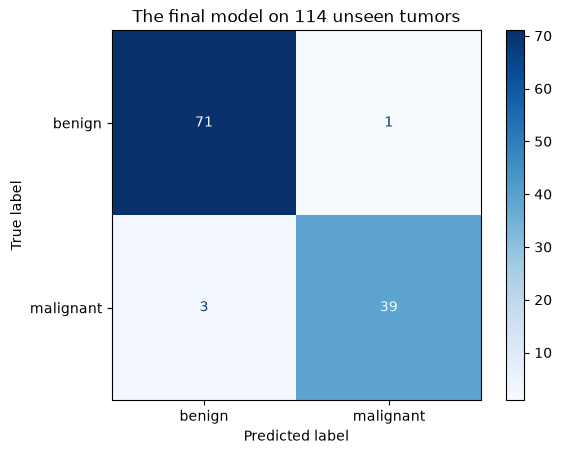

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["benign", "malignant"], cmap="Blues")
plt.title("The final model on 114 unseen tumors")
plt.show()